<a href="https://colab.research.google.com/github/Akshara495/kvasir_seg_polyp_segmentation/blob/main/kvasir_seg_polyp_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Polyp Segmentation on Kvasir-SEG — End-to-End Project
**U-Net with a pretrained ResNet-34 encoder (transfer learning).**

This notebook takes you from raw data to a trained model you can run on new images.
Run the cells **top to bottom**. Each section maps to one project step.

**How to use on Google Colab (recommended):**
1. Open [colab.research.google.com](https://colab.research.google.com) → *File → Upload notebook* → upload this file.
2. *Runtime → Change runtime type → T4 GPU → Save.*
3. Run each cell in order with **Shift+Enter**. Read the markdown above each cell first.

**What you're building:** a model that takes a colonoscopy image and outputs a mask marking the polyp (white) vs. everything else (black). This is *binary semantic segmentation*.

**Topics covered:** pixel-wise prediction · encoder–decoder / U-Net · transfer learning · Dice loss · IoU & Dice metrics · train/val discipline · freeze→unfreeze fine-tuning · error analysis.


## Step 1 — Install libraries & check the GPU
`segmentation-models-pytorch` gives us U-Net + a pretrained encoder in one line.
`albumentations` augments the image **and its mask together** (a flip must flip both).

If the GPU line prints `cuda`, you're set. If it prints `cpu`, go to
*Runtime → Change runtime type → T4 GPU* and re-run.

In [ ]:
# On Colab, torch/torchvision are preinstalled. We add the two segmentation libraries.
!pip install -q segmentation-models-pytorch albumentations

import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch:", torch.__version__)
print("Device :", DEVICE)
if DEVICE == "cpu":
    print("WARNING: no GPU. Enable it via Runtime > Change runtime type > T4 GPU.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.2 MB/s eta 0:00:00
PyTorch: 2.11.0+cu128
Device : cuda


In [ ]:
# Robust download + unzip for Kvasir-SEG (no -q, so errors are visible)
import os, ssl, zipfile, urllib.request

url = "https://datasets.simula.no/downloads/kvasir-seg.zip"
zip_path = "kvasir-seg.zip"

def have_valid_zip(p):
    return os.path.exists(p) and os.path.getsize(p) > 1_000_000  # real file is ~46 MB

if not have_valid_zip(zip_path):
    print("Downloading from Simula...")
    ctx = ssl.create_default_context(); ctx.check_hostname = False; ctx.verify_mode = ssl.CERT_NONE
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    try:
        with urllib.request.urlopen(req, context=ctx, timeout=180) as r, open(zip_path, "wb") as f:
            f.write(r.read())
        print("Downloaded:", round(os.path.getsize(zip_path)/1e6, 1), "MB")
    except Exception as e:
        print("DIRECT DOWNLOAD FAILED:", repr(e))
        print(">>> Use the Kaggle fallback cell below instead.")

if have_valid_zip(zip_path):
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(".")
    print("Unzipped.")

# Auto-find the images/masks folders wherever they landed
IMG_DIR = MASK_DIR = None
for root, dirs, _ in os.walk("."):
    low = {d.lower(): d for d in dirs}
    if "images" in low and "masks" in low:
        IMG_DIR  = os.path.join(root, low["images"])
        MASK_DIR = os.path.join(root, low["masks"])
        break

if IMG_DIR:
    print("IMG_DIR :", IMG_DIR, "->", len(os.listdir(IMG_DIR)), "files")
    print("MASK_DIR:", MASK_DIR, "->", len(os.listdir(MASK_DIR)), "files")
else:
    print("Folders not found yet — run the Kaggle fallback below.")

Unzipped.
IMG_DIR : ./Kvasir-SEG/images -> 1000 files
MASK_DIR: ./Kvasir-SEG/masks -> 1000 files


## Step 2 — Download & explore the dataset
Kvasir-SEG = 1000 colonoscopy images, each with a matching mask. Image and mask
share the same filename, so we can pair them by name.

**The one gotcha:** the masks are stored as **RGB images with the polyp in white (255)**
and background in black (0). A model needs class indices **0 and 1**, not 0 and 255.
We handle that conversion in the Dataset class in Step 3 — but let's first *look* at the data.

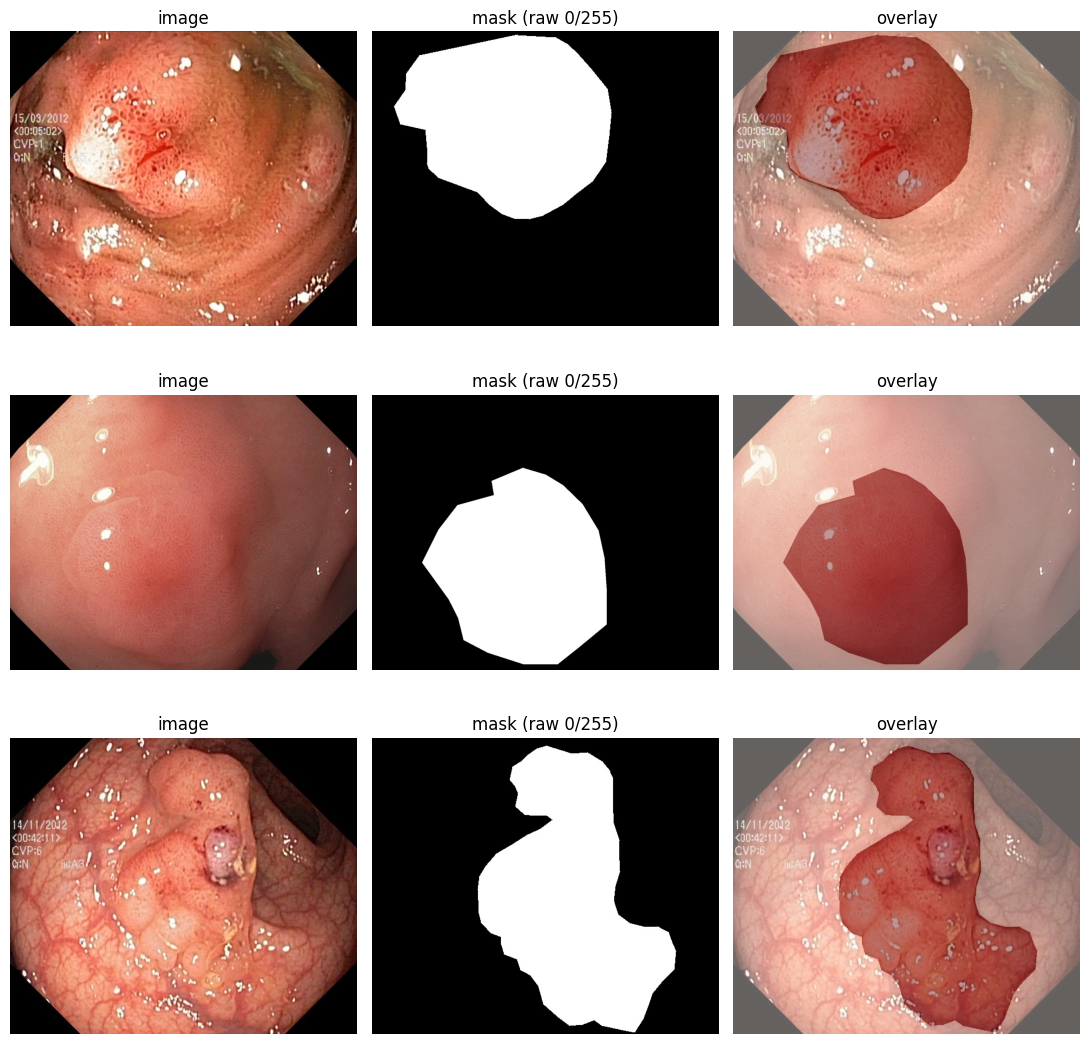

Unique values in a raw mask: [  0   1   2   3   4   5   6   7   8 247 248 249 250 251 252 253 254 255]


In [ ]:
# Look at 3 image/mask pairs. Always eyeball your data before modeling.
import glob, cv2, numpy as np, matplotlib.pyplot as plt

img_paths  = sorted(glob.glob(IMG_DIR + "/*.jpg"))
mask_paths = sorted(glob.glob(MASK_DIR + "/*.jpg"))

fig, ax = plt.subplots(3, 3, figsize=(11, 11))
for r in range(3):
    img  = cv2.cvtColor(cv2.imread(img_paths[r]), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_paths[r], cv2.IMREAD_GRAYSCALE)   # read as single channel
    ax[r,0].imshow(img);                 ax[r,0].set_title("image")
    ax[r,1].imshow(mask, cmap="gray");   ax[r,1].set_title("mask (raw 0/255)")
    ax[r,2].imshow(img); ax[r,2].imshow(mask, alpha=0.4, cmap="Reds"); ax[r,2].set_title("overlay")
    for c in range(3): ax[r,c].axis("off")
plt.tight_layout(); plt.show()

# Confirm the gotcha for yourself: the raw mask contains 0 and 255, not 0 and 1.
print("Unique values in a raw mask:", np.unique(cv2.imread(mask_paths[0], cv2.IMREAD_GRAYSCALE)))

## Step 3 — Build the data pipeline
A `Dataset` returns one `(image, mask)` pair at a time; a `DataLoader` batches them.

Key decisions here:
- **Resize** everything to a fixed size (the network needs constant dimensions).
- **Normalize** the image with **ImageNet mean/std** — the pretrained encoder was trained
  on ImageNet and expects inputs on that scale.
- **Convert the mask** from 0/255 to 0/1 (the gotcha).
- **Augment** train images (flips, rotations) to fight overfitting — `albumentations`
  applies the same geometric transform to the mask automatically.
- **Split** the 1000 pairs into train / validation so we can measure honestly.

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

IMG_SIZE = 256                      # 256x256 is a good balance of detail vs. speed
MEAN = (0.485, 0.456, 0.406)        # ImageNet statistics
STD  = (0.229, 0.224, 0.225)

# Pair images and masks by identical filename, then split.
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    img_paths, mask_paths, test_size=0.2, random_state=42)
print(f"Train pairs: {len(train_imgs)} | Val pairs: {len(val_imgs)}")

train_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])
val_tf = A.Compose([                # no augmentation on validation — we judge on clean data
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

class KvasirDataset(Dataset):
    def __init__(self, images, masks, transform):
        self.images, self.masks, self.transform = images, masks, transform
    def __len__(self):
        return len(self.images)
    def __getitem__(self, i):
        img  = cv2.cvtColor(cv2.imread(self.images[i]), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.masks[i], cv2.IMREAD_GRAYSCALE)   # single channel
        mask = (mask > 127).astype("float32")                    # 0/255 -> 0/1  (the gotcha)
        out  = self.transform(image=img, mask=mask)
        return out["image"], out["mask"]

train_ds = KvasirDataset(train_imgs, train_masks, train_tf)
val_ds   = KvasirDataset(val_imgs,   val_masks,   val_tf)

BATCH = 8                            # lower to 4 if you hit an out-of-memory error
train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

# Sanity check the shapes.
xb, yb = next(iter(train_dl))
print("image batch:", xb.shape, "| mask batch:", yb.shape, "| mask values:", torch.unique(yb))

Train pairs: 800 | Val pairs: 200
image batch: torch.Size([8, 3, 256, 256]) | mask batch: torch.Size([8, 256, 256]) | mask values: tensor([0., 1.])


## Step 4 — Build the model (U-Net + pretrained encoder)
One line creates the whole thing. Understand what it is:

- **Encoder** (`resnet34`, pretrained on ImageNet) shrinks the image while pulling out
  features — this is the **transfer learning**: it already knows edges, textures, shapes.
- **Decoder** grows the features back to full resolution to produce a per-pixel output.
- **Skip connections** pass fine detail from encoder to decoder so polyp edges stay sharp.
- `classes=1` → one output channel (binary). Output is raw **logits** (no activation);
  the loss applies the sigmoid internally.

In [ ]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",   # <-- transfer learning
    in_channels=3,
    classes=1,
    activation=None,              # output logits; loss handles sigmoid
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model ready. Total parameters: {n_params/1e6:.1f}M")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Model ready. Total parameters: 24.4M


## Step 5 — Loss and metrics
- **Loss (what we optimize):** Dice loss + BCE. Dice directly targets overlap and copes
  with imbalance (most pixels are background). BCE stabilizes early training.
- **Metrics (how we judge):** **IoU** and **Dice**. We deliberately **do not** use pixel
  accuracy — predicting "all background" scores ~95% here and is useless.

`get_stats` counts true/false positives/negatives per image; the reduction
`"micro-imagewise"` computes the score per image and averages — the standard way to
report segmentation quality.

In [ ]:
dice_loss = smp.losses.DiceLoss(mode="binary")
bce_loss  = torch.nn.BCEWithLogitsLoss()

def criterion(logits, target):
    return dice_loss(logits, target) + bce_loss(logits, target)

@torch.no_grad()
def batch_scores(logits, target):
    probs = logits.sigmoid()
    tp, fp, fn, tn = smp.metrics.get_stats(
        probs, target.long(), mode="binary", threshold=0.5)
    iou  = smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro-imagewise")
    dice = smp.metrics.f1_score (tp, fp, fn, tn, reduction="micro-imagewise")  # F1 == Dice
    return iou.item(), dice.item()

## Step 6 — Train
Strategy: **freeze the encoder first**, train only the decoder for a few epochs (fast, lets
the new decoder catch up to the pretrained features), then **unfreeze and fine-tune the whole
network** at a lower learning rate. This freeze→unfreeze pattern is the classic transfer-learning move.

We track train + validation loss every epoch and **save the checkpoint with the best
validation Dice** — that saved file is your final model.

Expect ~0.80+ Dice within a handful of epochs. On a T4, an epoch takes ~1 minute.

In [ ]:
from tqdm import tqdm

def set_encoder_trainable(flag: bool):
    for p in model.encoder.parameters():
        p.requires_grad = flag

def run_epoch(loader, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()
    tot_loss = tot_iou = tot_dice = 0.0
    for imgs, masks in tqdm(loader, leave=False):
        imgs  = imgs.to(DEVICE)
        masks = masks.unsqueeze(1).float().to(DEVICE)   # (B,H,W) -> (B,1,H,W)
        with torch.set_grad_enabled(train):
            logits = model(imgs)
            loss   = criterion(logits, masks)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
        iou, dice = batch_scores(logits, masks)
        tot_loss += loss.item(); tot_iou += iou; tot_dice += dice
    n = len(loader)
    return tot_loss/n, tot_iou/n, tot_dice/n

FROZEN_EPOCHS   = 3
UNFROZEN_EPOCHS = 7
history = {"train_loss": [], "val_loss": [], "val_iou": [], "val_dice": []}
best_dice = 0.0

for phase, (epochs, lr, freeze) in enumerate([
        (FROZEN_EPOCHS,   1e-3, True),     # phase 1: decoder only
        (UNFROZEN_EPOCHS, 1e-4, False)]):  # phase 2: whole network, lower LR
    set_encoder_trainable(not freeze)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    print(f"\n=== Phase {phase+1}: encoder {'FROZEN' if freeze else 'TRAINABLE'}, lr={lr} ===")
    for e in range(epochs):
        tr_loss, _, _        = run_epoch(train_dl, optimizer)
        va_loss, va_iou, va_dice = run_epoch(val_dl)
        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["val_iou"].append(va_iou);     history["val_dice"].append(va_dice)
        flag = ""
        if va_dice > best_dice:
            best_dice = va_dice
            torch.save(model.state_dict(), "best_model.pth")
            flag = "  <- saved (best)"
        print(f"epoch {e+1:02d} | train_loss {tr_loss:.3f} | "
              f"val_loss {va_loss:.3f} | val_IoU {va_iou:.3f} | val_Dice {va_dice:.3f}{flag}")

print(f"\nBest validation Dice: {best_dice:.3f}  (saved to best_model.pth)")


=== Phase 1: encoder FROZEN, lr=0.001 ===


epoch 01 | train_loss 0.714 | val_loss 0.530 | val_IoU 0.557 | val_Dice 0.673  <- saved (best)


epoch 02 | train_loss 0.510 | val_loss 0.466 | val_IoU 0.600 | val_Dice 0.710  <- saved (best)


epoch 03 | train_loss 0.468 | val_loss 0.434 | val_IoU 0.640 | val_Dice 0.746  <- saved (best)

=== Phase 2: encoder TRAINABLE, lr=0.0001 ===


epoch 01 | train_loss 0.406 | val_loss 0.330 | val_IoU 0.737 | val_Dice 0.825  <- saved (best)


...

epoch 03 | train_loss 0.280 | val_loss 0.295 | val_IoU 0.762 | val_Dice 0.845  <- saved (best)


epoch 04 | train_loss 0.292 | val_loss 0.282 | val_IoU 0.772 | val_Dice 0.848  <- saved (best)


epoch 05 | train_loss 0.238 | val_loss 0.274 | val_IoU 0.779 | val_Dice 0.852  <- saved (best)


epoch 06 | train_loss 0.256 | val_loss 0.243 | val_IoU 0.797 | val_Dice 0.866  <- saved (best)


epoch 07 | train_loss 0.230 | val_loss 0.242 | val_IoU 0.800 | val_Dice 0.871  <- saved (best)

Best validation Dice: 0.871  (saved to best_model.pth)


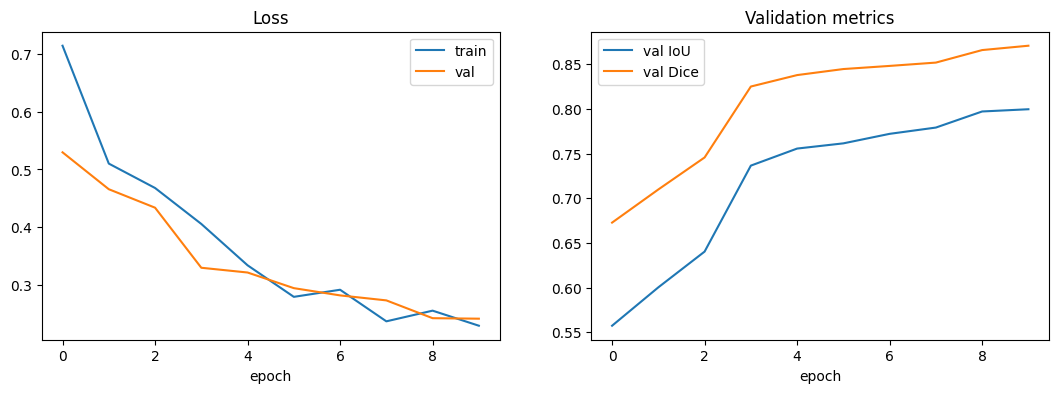

In [ ]:
# Plot the learning curves. Train loss falling while val loss flattens/rises = overfitting.
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(history["train_loss"], label="train"); ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(history["val_iou"], label="val IoU"); ax[1].plot(history["val_dice"], label="val Dice")
ax[1].set_title("Validation metrics"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.show()

## Step 7 — Evaluate & error analysis
Load the **best** checkpoint, then do two things:
1. Report final validation IoU/Dice — the number for your writeup.
2. **Look at predictions**, especially the worst ones. *Where* the model fails (tiny polyps?
   blurry edges? unusual color?) is the most valuable thing you can put in a report, and
   it's what separates a real project from a tutorial.

In [ ]:
# Restore the best weights.
model.load_state_dict(torch.load("best_model.pth", map_location=DEVICE))
model.eval()

# Per-image Dice across the whole validation set, so we can rank best/worst.
per_image = []
with torch.no_grad():
    for i in range(len(val_ds)):
        img, mask = val_ds[i]
        logits = model(img.unsqueeze(0).to(DEVICE))
        _, dice = batch_scores(logits, mask.unsqueeze(0).unsqueeze(0).to(DEVICE))
        per_image.append((dice, i))

per_image.sort()
mean_dice = sum(d for d, _ in per_image) / len(per_image)
print(f"Mean validation Dice: {mean_dice:.3f}")
print(f"Worst image Dice: {per_image[0][0]:.3f} | Best image Dice: {per_image[-1][0]:.3f}")

Mean validation Dice: 0.871
Worst image Dice: 0.000 | Best image Dice: 0.981


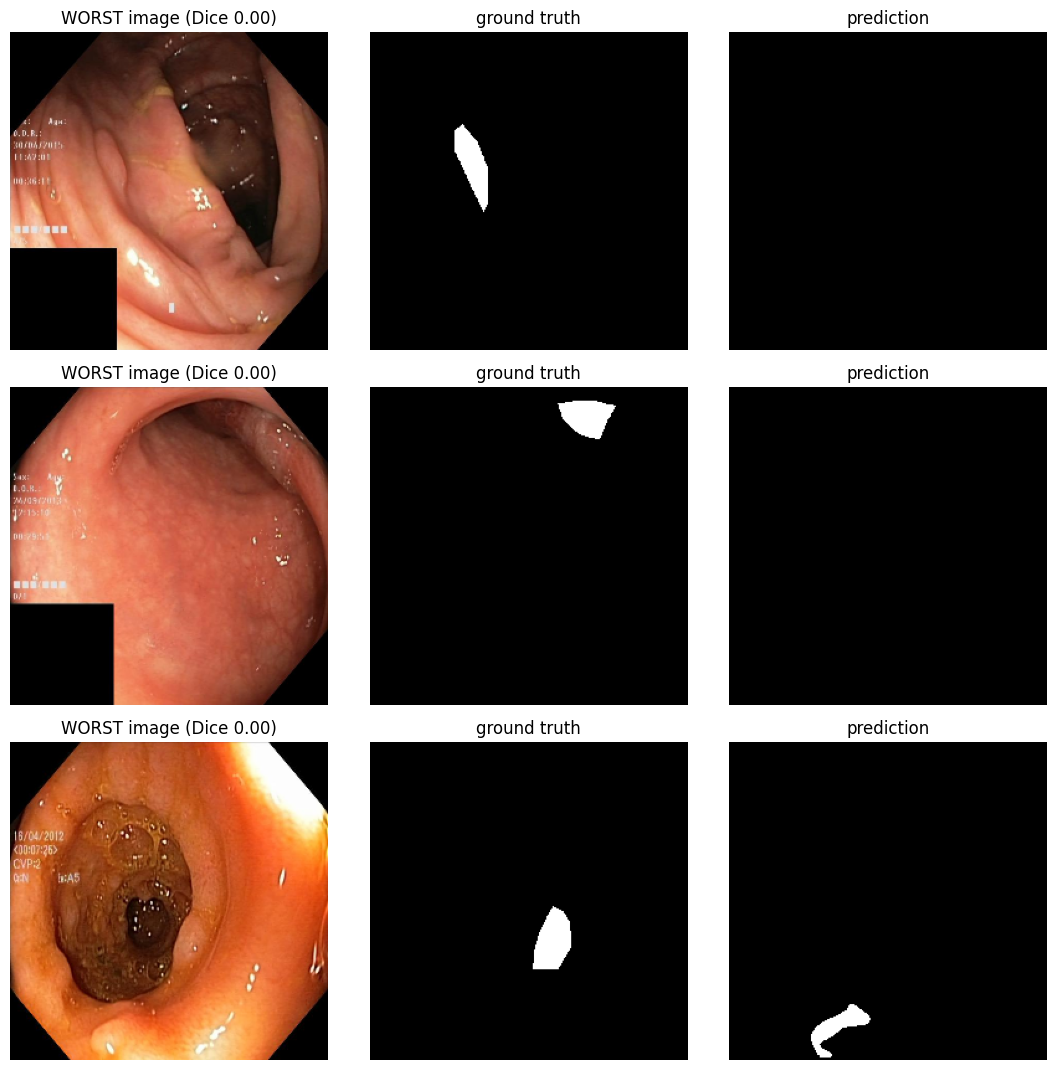

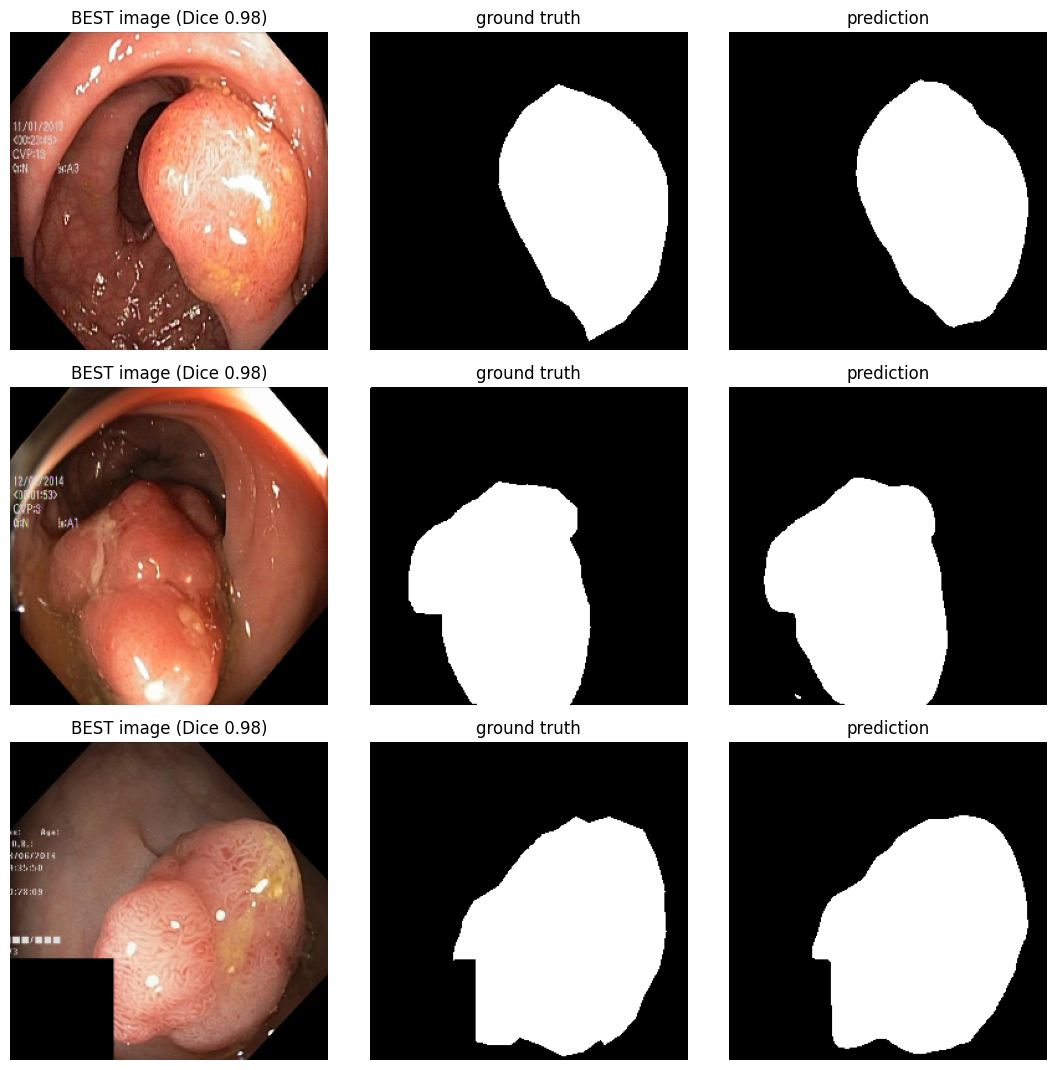

In [ ]:
# Visualize: worst 3 (top rows) and best 3 (bottom rows). image | ground truth | prediction
def show(idx_list, tag):
    fig, ax = plt.subplots(len(idx_list), 3, figsize=(11, 3.6*len(idx_list)))
    for r, (dice, i) in enumerate(idx_list):
        img, mask = val_ds[i]
        with torch.no_grad():
            pred = (model(img.unsqueeze(0).to(DEVICE)).sigmoid() > 0.5).float().cpu().squeeze().numpy()
        # undo normalization for display
        disp = img.permute(1,2,0).numpy() * np.array(STD) + np.array(MEAN)
        disp = np.clip(disp, 0, 1)
        ax[r,0].imshow(disp);                 ax[r,0].set_title(f"{tag} image (Dice {dice:.2f})")
        ax[r,1].imshow(mask, cmap="gray");    ax[r,1].set_title("ground truth")
        ax[r,2].imshow(pred, cmap="gray");    ax[r,2].set_title("prediction")
        for c in range(3): ax[r,c].axis("off")
    plt.tight_layout(); plt.show()

show(per_image[:3],  "WORST")   # study these failures
show(per_image[-3:], "BEST")

## Step 8 — Ideas to improve (optional, do one at a time)
Change **one** thing, retrain, and compare the number honestly. That "change one thing, measure it"
discipline is exactly what makes a strong writeup. Things worth trying:
- Train **longer** (raise `UNFROZEN_EPOCHS`) and watch for overfitting in the curves.
- Swap the encoder: `encoder_name="efficientnet-b0"` or `"resnet50"` in Step 4.
- Add augmentations aimed at your observed failures (e.g. `A.RandomBrightnessContrast`,
  `A.ElasticTransform`) in the `train_tf` in Step 3.
- Try a different architecture: `smp.UnetPlusPlus(...)` or `smp.FPN(...)` — same arguments.

Keep a small table: *what I changed → val Dice before → after.* That table is a resume-grade artifact.

## Step 9 — Run on a new image & save your model
This is your "demo": feed any colonoscopy image, get a polyp mask. `best_model.pth`
is the file to keep — download it (Colab: *Files panel → right-click → Download*) or
save it to Google Drive.

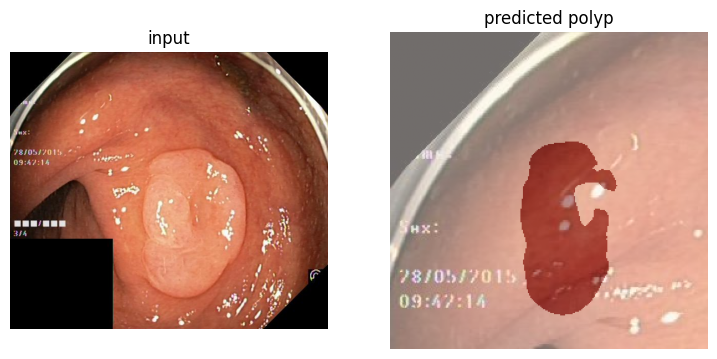

In [ ]:
def predict(image_path):
    img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    tensor = val_tf(image=img, mask=np.zeros(img.shape[:2], "float32"))["image"]
    with torch.no_grad():
        pred = (model(tensor.unsqueeze(0).to(DEVICE)).sigmoid() > 0.5).float().cpu().squeeze().numpy()
    fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
    ax[0].imshow(img);              ax[0].set_title("input");          ax[0].axis("off")
    ax[1].imshow(img)
    ax[1].imshow(pred, alpha=0.45, cmap="Reds"); ax[1].set_title("predicted polyp"); ax[1].axis("off")
    plt.show()
    return pred

# Demo on a validation image (swap in any path, including your own uploads).
_ = predict(val_imgs[0])

# (Optional) copy the model to Google Drive so it survives the session:
# from google.colab import drive; drive.mount('/content/drive')
# !cp best_model.pth /content/drive/MyDrive/

## What to write in your README / report
Keep it short and honest — this is what turns code into a portfolio piece:
1. **Task & data:** binary polyp segmentation, Kvasir-SEG (1000 images), 80/20 split.
2. **Method:** U-Net + ImageNet-pretrained ResNet-34; Dice+BCE loss; freeze→unfreeze fine-tuning.
3. **Result:** final mean validation Dice / IoU (the numbers from Step 7).
4. **Error analysis:** 2–3 sentences on *where* it failed (from the WORST images) and your guess why.
5. **What you'd try next:** one or two items from Step 8.

You can defend every line of this because you built and measured each part.
